# 08 — Marketing scenario planning

Marketing and operations plan separately in most networks: marketing buys
demand, operations staffs for it, and the two meet in a corridor when a
campaign overwhelms a clinic. This notebook closes that loop — it estimates
how *planned changes to marketing inputs* propagate through the demand
forecast into staffing needs.

## Assumptions, stated up front

1. **This is what-if analysis, not causal inference.** The model's
   spend-demand relationship is learned from observational history where
   campaigns cluster in high season. Scenario deltas mean "what the model
   expects under this plan", not "what marketing causes".
2. **The baseline marketing plan** is each clinic's recent spend carried
   forward by weekday (the batch pipeline's documented assumption).
3. **Everything else is held fixed** — calendar, opening days, clinic mix.
   Scenarios edit only the marketing columns of the future inputs.
4. **Results are reproducible**: same data, same seed, same scenario, same
   numbers (asserted in the test suite).

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (11, 4)

from clinic_forecast.data import generate_network_data

data_path = PROJECT_ROOT / "data" / "processed" / "clinic_daily_usage.csv"
if data_path.exists():
    usage = pd.read_csv(data_path, parse_dates=["date"])
    metadata = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "clinic_metadata.csv")
else:
    network = generate_network_data()
    usage, metadata = network.usage, network.metadata
    usage["date"] = pd.to_datetime(usage["date"])

## Setup: model and planning window

The global ML model is fit on all history; the planning window is the next
28 days, with future inputs built exactly as the batch pipeline builds them.

In [2]:
from clinic_forecast.models.global_ml import GlobalMLForecaster
from clinic_forecast.pipelines.batch_inference import make_future_frame

model = GlobalMLForecaster().fit(usage)
future = make_future_frame(usage, metadata, horizon_days=28)
print(f"Planning window: {future['date'].min():%Y-%m-%d} to {future['date'].max():%Y-%m-%d}")

Planning window: 2026-01-01 to 2026-01-28


## Four plans

| Scenario | Edit |
| --- | --- |
| baseline | The carried-forward marketing plan, unchanged |
| spend_up_50 | All channels, all clinics: spend x1.5 |
| spend_down_50 | All channels, all clinics: spend x0.5 |
| north_campaign | North-region clinics only: spend x2 and campaign flag forced on |

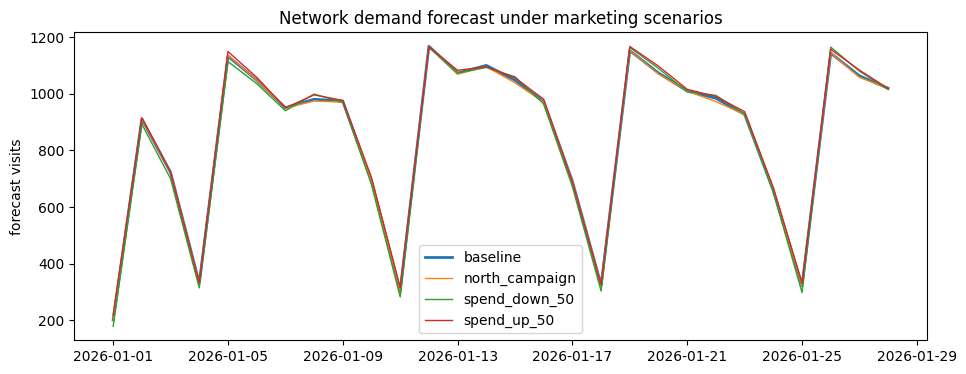

In [3]:
from clinic_forecast.scenarios import (
    MarketingScenario, scenario_forecasts, scenario_staffing_impact,
)

scenarios = [
    MarketingScenario(name="spend_up_50", spend_multiplier=1.5),
    MarketingScenario(name="spend_down_50", spend_multiplier=0.5),
    MarketingScenario(
        name="north_campaign", spend_multiplier=2.0,
        regions=("north",), set_campaign_active=True,
    ),
]
forecasts = scenario_forecasts(model, usage, future, scenarios, metadata=metadata)
network_daily = (
    forecasts.groupby(["scenario", "date"], as_index=False)["forecast"].sum()
)

fig, ax = plt.subplots()
for scenario, frame in network_daily.groupby("scenario"):
    ax.plot(frame["date"], frame["forecast"], label=scenario,
            linewidth=2.0 if scenario == "baseline" else 1.0)
ax.set_title("Network demand forecast under marketing scenarios")
ax.set_ylabel("forecast visits")
ax.legend()
plt.show()

## Incremental demand and staffing impact

In [4]:
impact = scenario_staffing_impact(forecasts)
impact.round(0)

,scenario,total_visits,incremental_visits,clinician_days,clinician_day_delta
0,spend_down_50,23829.0,-147.0,1674,2
1,north_campaign,23927.0,-49.0,1666,-6
2,baseline,23976.0,0.0,1672,0
3,spend_up_50,24200.0,224.0,1692,20


In [5]:
north_clinics = metadata[metadata["region"] == "north"]["clinic_id"]
regional = forecasts[
    (forecasts["scenario"] == "north_campaign")
    & (forecasts["clinic_id"].isin(north_clinics))
]
spillover = forecasts[
    (forecasts["scenario"] == "north_campaign")
    & (~forecasts["clinic_id"].isin(north_clinics))
]
print(f"North campaign - incremental visits in north clinics: "
      f"{regional['incremental_visits'].sum():,.0f}")
print(f"North campaign - incremental visits elsewhere (should be ~0): "
      f"{spillover['incremental_visits'].sum():,.0f}")

North campaign - incremental visits in north clinics: -49
North campaign - incremental visits elsewhere (should be ~0): 0


How to read the results:

- **Asymmetry is expected.** The model's marketing response has diminishing
  returns (log-shaped in the underlying demand process), so +50% spend buys
  less demand than -50% spend removes. Scenario planning surfaces exactly
  this kind of nonlinearity that a flat "visits per euro" rule would miss.
- **The regional campaign stays regional.** Incremental demand concentrates
  in north clinics; other clinics are untouched because their inputs did not
  change. The staffing delta tells operations how many extra clinician-days
  the campaign commits them to *before* it launches.
- **The staffing column is the point.** Marketing proposals can now arrive
  with their operational price attached: a campaign that needs clinician-days
  a region cannot roster is a problem found in planning, not in the waiting
  room.

## Limitations

- Confounding: campaigns historically coincide with high season, so part of
  the learned response may be seasonal. A causal estimate would need
  experimentation (geo holdouts) — out of scope and explicitly not claimed.
- Channel mix effects are only as good as the model's channel features;
  small channels with little historical variation carry little signal.
- Scenario edits to spend assume execution matches plan.